In [1]:
import os
import time
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy import integrate
from copy import deepcopy


# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

In [3]:
MGL = MGLensing.MGL("config_ccl_comparison.yaml")
zz = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin


l_wl_max, l_gc_max = MGL.Survey.ells_wl_max, MGL.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL.Survey.l_wl, MGL.Survey.l_gc, MGL.Survey.l_xc

Source galaxy distribution for bin  0  integrates to  0.9999201944616665
Lens galaxy distribution for bin  0  integrates to  1.0000005679267678
Source galaxy distribution for bin  1  integrates to  1.000000581682923
Lens galaxy distribution for bin  1  integrates to  1.0000007725408466
Source galaxy distribution for bin  2  integrates to  1.0000005285358693
Lens galaxy distribution for bin  2  integrates to  1.000000501287934
Source galaxy distribution for bin  3  integrates to  0.9999996535305957
Lens galaxy distribution for bin  3  integrates to  0.9999997816368513
Source galaxy distribution for bin  4  integrates to  0.9872862583339359
Lens galaxy distribution for bin  4  integrates to  1.0000000029598894
model["nl_model"] =  0
initialising hmcode


Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  240
gc_masked_ells:  178
xc_masked_ells:  295
3x2pt_masked_ells:  713
computing data covariance


cov_flat:  (1100, 1100)
cov_flat_masked:  (713, 713)
managed to do cholesky decomposition
######CHOLESKY!!!!########
finish computing mock data
################################
model["nl_model"] =  0
initialising hmcode
Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for theory....
all good with the model parameters
################################


In [4]:
params = {
    'Omega_m' :  0.315,
    'Omega_c' :  0.315-0.05,
    'Omega_cb' :  0.315,
    'Omega_nu':  0.,
    'As'      :  np.exp(3.07)*1.e-10,
    'Omega_b' :  0.05,
    'ns'      :  0.96,
    'h'       :  0.67,
    'Mnu'     :  0.0,
    'w0'      :  -1.0,
    'wa'      :  0.0,
    'a1_IA': 0.16,
    'eta1_IA': 1.66,
    'beta_IA': 0.,
    # modified gravity parameters

    # Hu-Sawicki f(R)
    'log10f_R0': -5.0,
}

b0 = 0.68
bias1_arr = np.array([b0*(1.+z_bin_center_i) for z_bin_center_i in MGL.Survey.z_bin_center_l ])
for bin_i in range(nbin):
    params[f'b1_{bin_i+1}']=bias1_arr[bin_i]

In [5]:
# first call MGL
NL_MODEL_HMCODE = 0
NL_MODEL_BACCO = 1
NL_MODEL_NDGP = 2
NL_MODEL_GAMMAZ = 3
NL_MODEL_MUSIGMA = 4
NL_MODEL_DS = 5
NL_MODEL_FOFR = 6


models = {
    'GR_nonlin': {'nl_model': NL_MODEL_HMCODE, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'GR_lin': {'nl_model': NL_MODEL_HMCODE, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'fofR_nonlin': {'nl_model': NL_MODEL_FOFR, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'fofR_lin': {'nl_model': NL_MODEL_FOFR, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'fofR_pseudo': {'nl_model': NL_MODEL_FOFR, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    }

In [6]:
power_spectra = {}
for model_opt in models:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
            'pgm': pgm,
            'pgg': pgg
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  0
initialising hmcode
Model: GR_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  0
initialising hmcode


Model: GR_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Model: fofR_nonlin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode


Model: fofR_lin, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
Model: fofR_pseudo, k_ell shape: (20, 360), pmm shape: (20, 360), pgm shape: (20, 360, 5), pgg shape: (20, 360, 5, 5)


In [7]:
_, rcom = MGL.get_expansion_and_rcom(params)
# pick 3 redshifts
z_int_pick = [80, 100, 120] #goes from 0 to 255
def k2ell(x, ind=z_int_pick[0]):
    return x*rcom[ind]-0.5
def ell2k(x, ind=z_int_pick[0]):
    return (x+0.5)/rcom[ind]
def k2ell1(x, ind=z_int_pick[1]):
    return x*rcom[ind]-0.5
def ell2k1(x, ind=z_int_pick[1]):
    return (x+0.5)/rcom[ind]
def k2ell2(x, ind=z_int_pick[2]):
    return x*rcom[ind]-0.5
def ell2k2(x, ind=z_int_pick[2]):
    return (x+0.5)/rcom[ind]
f_arr = [k2ell, k2ell1, k2ell2]
f_inv_arr = [ell2k, ell2k1, ell2k2]
# pick the bins
bin_i=2
bin_j=3

In [8]:
colors = sns.color_palette("Paired")
model_opt_nonlin = ['fofR_nonlin', 'fofR_pseudo']
model_opt_lin = ['fofR_lin']
labels = ['nonlin', 'pseudo']

  ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=False, title_fontsize=20)



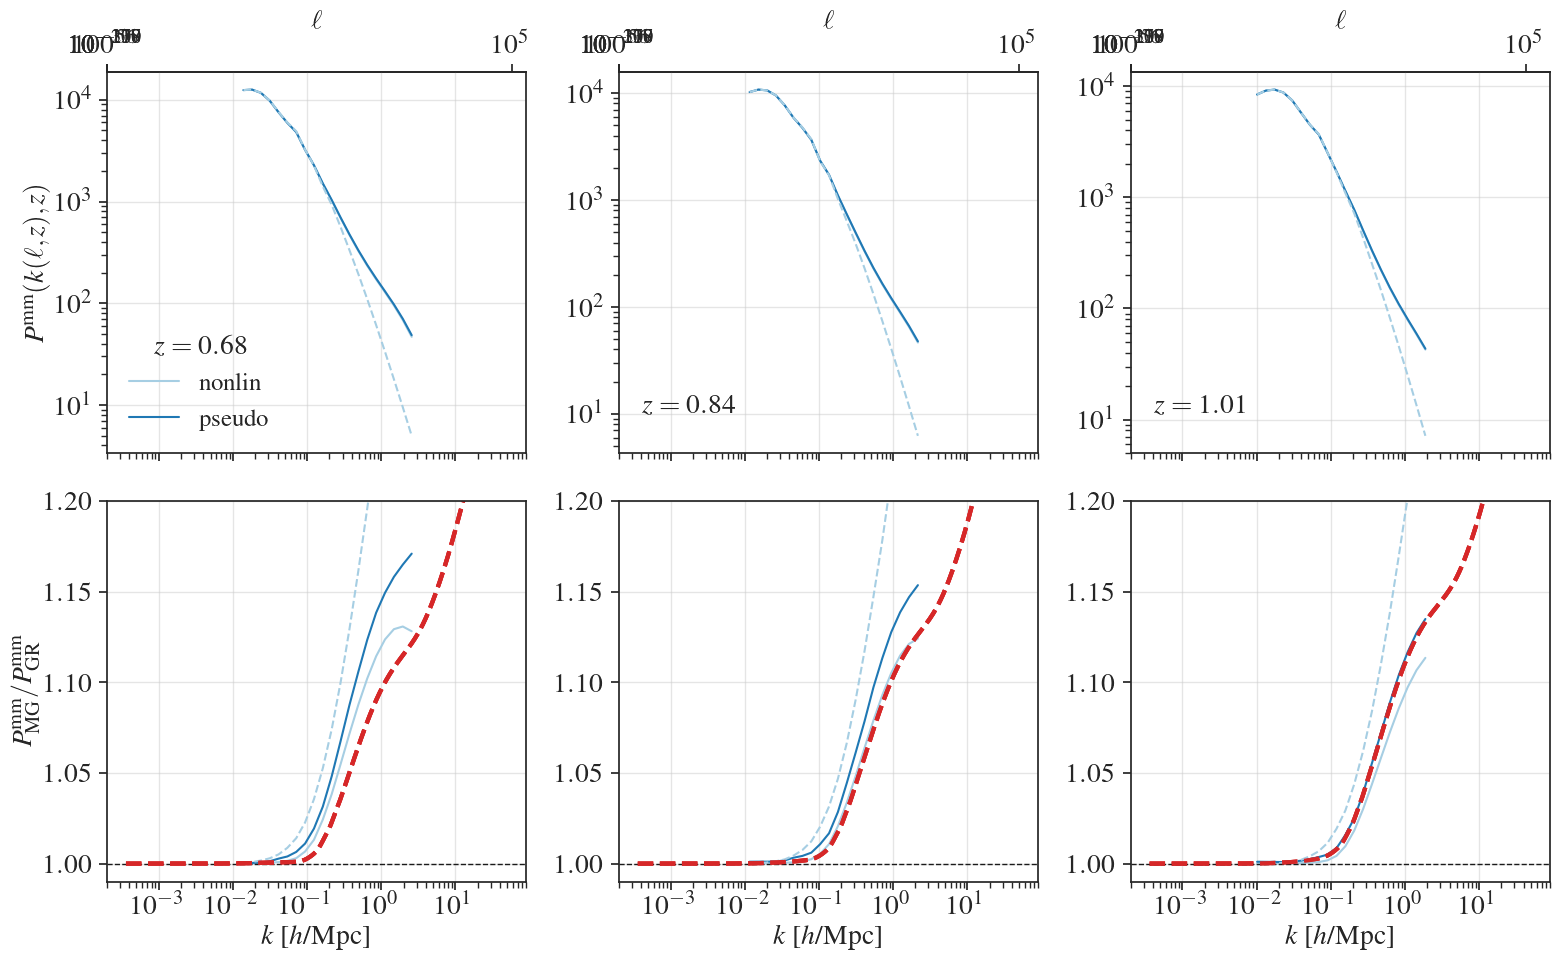

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10), facecolor='w', gridspec_kw={'height_ratios':[1,1] }, sharex=True)
pmm_gr_nl = power_spectra['GR_nonlin']['pmm']
pmm_gr_lin = power_spectra['GR_lin']['pmm']

for i in range(3):
    for j, model_opt in enumerate(model_opt_nonlin):
        k_ell = power_spectra[model_opt]['k']
        pmm = power_spectra[model_opt]['pmm']
        ax[0][i].loglog(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]], linewidth=1.5, color = colors[j], label=labels[j] if i == 0 else '')
        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[j])
    for j, model_opt in enumerate(model_opt_lin):
        k_ell = power_spectra[model_opt]['k']
        pmm = power_spectra[model_opt]['pmm']
        ax[0][i].loglog(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle='--')
        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[j], linestyle='--')
    ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='lower left', frameon=False, title_fontsize=20)
    ax[1][i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[0][i].grid(alpha=0.5)
    ax[1][i].grid(alpha=0.5)
    ax[1][i].set_ylim(0.99, 1.2)    
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)  
    ax[1][2].semilogx(kh_lin, Pk_hm_fR_z1[-1]/Pk_hm_GR[-1], color='tab:red', linestyle='--') 
    ax[1][1].semilogx(kh_lin, Pk_hm_fR_z1[-2]/Pk_hm_GR[-2], color='tab:red', linestyle='--') 
    ax[1][0].semilogx(kh_lin, Pk_hm_fR_z1[1]/Pk_hm_GR[1], color='tab:red', linestyle='--') 
ax[0][0].set_ylabel("$P^{\\rm mm}(k(\ell, z), z)$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm MG}/P_{\\rm GR}^{\\rm mm}$")
plt.tight_layout()

In [9]:
import pyhmcode as hmcode
hmc = hmcode.Cosmology()

# Set HMcode internal cosmological parameters
hmc.om_m = params['Omega_m']
hmc.om_b = params['Omega_b']
hmc.om_v = 1.-params['Omega_m']
hmc.h = params['h']
hmc.ns = params['ns']
hmc.sig8 = MGL.TheoryModel.StructureEmu.get_sigma8_lcdm(params)[0]
hmc.m_nu = 0.

z_react = np.array([0., 0.68, 0.84, 1.01])

In [10]:
from cosmopower import cosmopower_NN
from scipy.interpolate import RectBivariateSpline, interp1d

cp_lin_model = cosmopower_NN(restore=True, 
                      restore_filename='emulators/log10_total_matter_linear_emu',
                      )
kh_lin = cp_lin_model.modes # 3.7e-4..50. h/Mpc 
        

In [11]:
def get_pk_hmcode_lin_interp(params_dic, zz_pk):
        ns   = params_dic['ns']
        a_s   = params_dic['As']
        h    = params_dic['h']
        omega_b = params_dic['Omega_b']
        omega_c = params_dic['Omega_c']
        nz_pk = len(zz_pk)
        params_hmcode = {
                'ns'            :  np.full(nz_pk, ns),
                'As'            :  np.full(nz_pk, a_s),
                'hubble'        :  np.full(nz_pk, h),
                'omega_baryon'  :  np.full(nz_pk, omega_b),
                'omega_cdm'     :  np.full(nz_pk, omega_c),
                'neutrino_mass' :  np.zeros(nz_pk),
                'w0'            :  np.full(nz_pk, -1.),
                'wa'            :  np.zeros(nz_pk),
                'z'             :  zz_pk
            }
        plin_cp = cp_lin_model.ten_to_predictions_np(params_hmcode)
        plin_interp = RectBivariateSpline(zz_pk,
                            kh_lin,
                            plin_cp,
                            kx=1, ky=1)     
        return  plin_interp

In [12]:
import MGrowth as mg

def get_growth(params_dic, zz_integr):
        aa_integr =  np.array(1./(1.+zz_integr[::-1]))
        background ={
            'Omega_m': params_dic['Omega_m'],
            'h' : params_dic['h'],
            'w0': -1.,
            'wa': 0.,
            'a_arr': np.hstack((aa_integr, 1.))
            }
        cosmo = mg.fR_HS(background)
        fr0    = 10**params_dic['log10f_R0']
        da, _ = cosmo.growth_parameters(kh_lin, fr0)  
        dz = da[:, ::-1] 
        # growth factor should be normalised to z=0
        # return array of k and z
        dz0 = dz[:, 0]
        dz = dz[:, 1:]/dz0[:, None]
        return dz, dz0[:, None]
    
def get_growth_lcdm(params_dic, zz_integr):
    aa_integr =  np.array(1./(1.+zz_integr[::-1]))
    background ={
        'Omega_m': params_dic['Omega_m'],
        'h' : params_dic['h'],
        'w0': -1.,
        'wa': 0.,
        'a_arr': np.hstack((aa_integr, 1.))
        }
    cosmo = mg.LCDM(background)
    da, _ = cosmo.growth_parameters()  
    dz = da[::-1] 
    # growth factor should be normalised to z=0
    # return array of z
    dz0 = dz[0]
    dz = dz[1:]/dz0
    return dz, dz0

In [13]:
dz_fr0, dz0_fr0 = get_growth(params, z_react)
dz_fr0_notnorm = dz_fr0*dz0_fr0
dz_lcdm, dz0_lcdm = get_growth_lcdm(params, z_react)
dz_norm = (dz_fr0_notnorm/dz0_lcdm)**2
interp = get_pk_hmcode_lin_interp(params, z_react)
pofk_lin_MG_react = interp(0., kh_lin)*dz_norm.T
dz_lcdm_notnorm = dz_lcdm*dz0_lcdm
pofk_lin_gr = interp(0., kh_lin)*dz_lcdm[:, None]**2

In [14]:
# Set the halo model in HMcode
# Options: HMcode2015, HMcode2016, HMcode2020
hmod = hmcode.Halomodel(hmcode.HMcode2020, verbose=False)
# Power spectrum calculation for f(R)
# z_f = 0
hmc.set_linear_power_spectrum(kh_lin, np.asarray(z_react), pofk_lin_MG_react)
Pk_hm_fR = hmcode.calculate_nonlinear_power_spectrum(hmc, hmod, verbose=False)





In [15]:
# z_f = 1
D_LCDM_z1 = dz_lcdm_notnorm[-1]
D_LCDM_z0 = dz_lcdm_notnorm[0]

pofk_lin_MG_react_new = np.zeros(pofk_lin_MG_react.shape)
for j in [1, 2, 3]:
    for i in range(len(pofk_lin_MG_react[1])):
        pofk_lin_MG_react_new[j][i] = pofk_lin_MG_react[j][i]        
for i in range(len(pofk_lin_MG_react[0])):       
    pofk_lin_MG_react_new[0][i] = (D_LCDM_z0/D_LCDM_z1)**2 * pofk_lin_MG_react[-1][i]

    
hmc.set_linear_power_spectrum(kh_lin, np.asarray(z_react), pofk_lin_MG_react_new)    
Pk_hm_fR_z1 = hmcode.calculate_nonlinear_power_spectrum(hmc, hmod, verbose=False)  

In [16]:
pofk_lin_gr.shape
pofk_lin_MG_react.shape

(4, 462)

In [17]:
hmc.set_linear_power_spectrum(kh_lin, np.asarray(z_react), pofk_lin_gr)
Pk_hm_GR = hmcode.calculate_nonlinear_power_spectrum(hmc, hmod, verbose=False)  